# Bond Market Making with a Hit-Ratio Target
### Implementation Notebook

**Paper:** Barzykin, A. & Ciceri, A. (2026). *Bond Market Making with a Hit-Ratio Target*. arXiv:2604.20406.  
**Affiliation:** HSBC, Canary Wharf, London  

---

## Paper Overview

This paper extends the Bergault–Guéant (BEGV) OTC market-making framework to **corporate bond RFQ (request-for-quote) markets** by adding an explicit **hit-ratio target** as a running control objective.

**Core contributions:**
1. Formulates a stochastic control problem for a dealer quoting on a size ladder, with quadratic inventory penalty *and* a quadratic penalty for deviating from a target hit ratio.
2. Shows the resulting HJB equation is **separable** after dualising the hit-ratio term, yielding exact optimal controls via the inverse fill-probability function.
3. Applies the BEGV quadratic approximation, reducing the problem to a **matrix Riccati equation** for the inventory curvature (identical form to BEGV) plus a scalar dual-variable closure for the hit-ratio multiplier.
4. Derives **linearised quote decompositions**: riskless spread + inventory-risk correction + hit-ratio correction.
5. Validates numerically across single-bond, multi-tier, and multi-bond scenarios.


## 1. Setup

Imports, random seed, and shared constants used throughout the notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.linalg import expm, sqrtm
from scipy.optimize import brentq
from copy import deepcopy


def _find_repo_root() -> Path:
    for path in (Path.cwd(), *Path.cwd().parents):
        if (path / "pyproject.toml").is_file():
            return path
    raise FileNotFoundError("Could not find repo root (pyproject.toml)")


OUTPUT_DIR = _find_repo_root() / "outputs" / "notebooks" / "bond_market_making_hit_ratio"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'lines.linewidth': 1.8,
})

print(f"All imports OK. Figures → {OUTPUT_DIR}")

All imports OK. Figures → /Users/yuriturygin/Documents/GitHub/algo_market_making/outputs/notebooks/bond_market_making_hit_ratio


## 2. Model Primitives

### Fill-probability and Hamiltonian functions

Per §2.1 the fill probability is a sigmoid parameterised by α (scale) and β (sensitivity):

$$f(δ) = \frac{α}{1 + e^{β δ}}$$

The **Hamiltonian** (§2.2, Eq. 14) is

$$H(p) = \sup_{δ} Λ(δ)(δ - p) = λ \sup_{δ} f(δ)(δ - p)$$

with maximiser (Eq. 15)

$$\tilde{δ}(p) = (f^{-1})\!\left(-H'(p)/λ\right)$$

Under the sigmoid model this yields closed forms used in the BEGV quadratic expansion.


In [2]:
# ── Fill probability (sigmoid) ─────────────────────────────────────────────
# f(δ) = α / (1 + exp(β δ))   (§2.1, Eq. 2)

def fill_prob(delta, alpha, beta):
    """Sigmoid fill probability."""
    return alpha / (1.0 + np.exp(beta * delta))

def fill_prob_prime(delta, alpha, beta):
    """df/dδ"""
    e = np.exp(beta * delta)
    return -alpha * beta * e / (1.0 + e)**2

def fill_prob_double_prime(delta, alpha, beta):
    """d²f/dδ²"""
    e = np.exp(beta * delta)
    return alpha * beta**2 * e * (e - 1.0) / (1.0 + e)**3

# ── Hamiltonian and its derivatives ────────────────────────────────────────
# H(p) = sup_δ  λ f(δ)(δ - p)   (§2.2, Eq. 14)
# Solved numerically for each (p, α, β, λ).

def hamiltonian(p, lam, alpha, beta, n_grid=500):
    """H(p) = sup_δ Λ(δ)(δ - p).  Eq. (14)."""
    deltas = np.linspace(-10, 10, n_grid)
    vals = lam * fill_prob(deltas, alpha, beta) * (deltas - p)
    return float(np.max(vals))

def optimal_delta_exact(p, lam, alpha, beta, n_grid=500):
    """arg max_δ Λ(δ)(δ - p).  Eq. (15)."""
    deltas = np.linspace(-10, 10, n_grid)
    vals = lam * fill_prob(deltas, alpha, beta) * (deltas - p)
    return float(deltas[np.argmax(vals)])

# ── Riskless spread δ₀  (p=0 maximiser)  ──────────────────────────────────
# δ̃₀ = argmax_δ Λ(δ)δ   (§2.4, Eq. 34)

def riskless_spread(lam, alpha, beta):
    return optimal_delta_exact(0.0, lam, alpha, beta)

# ── BEGV quadratic expansion primitives  ──────────────────────────────────
# H'(0) = -Λ(δ̃₀),   H''(0) = Λ(δ̃₀)/(δ̃₀ · c)   (Eq. 37)
# c = 2 - f(δ̃₀)f''(δ̃₀) / (f'(δ̃₀))²             (Eq. 36)

def begv_primitives(lam, alpha, beta):
    """Returns (H'(0), H''(0), δ̃₀, c) for one (s,k,m,τ) cell.  Eq. 36-37."""
    d0 = riskless_spread(lam, alpha, beta)
    f0   = fill_prob(d0, alpha, beta)
    fp0  = fill_prob_prime(d0, alpha, beta)
    fpp0 = fill_prob_double_prime(d0, alpha, beta)
    Lambda0 = lam * f0
    c = 2.0 - f0 * fpp0 / fp0**2
    Hp0  = -Lambda0            # H'(0)
    Hpp0 = Lambda0 / (d0 * c) # H''(0)  (δ̃₀ > 0 in normal market)
    return Hp0, Hpp0, d0, c

print("Primitives defined.")


Primitives defined.


## 3. Single-Bond, Single-Tier Scenario

Per §3: size ladder **z = (1, 5, 20) M**, baseline intensities **λ = (500, 200, 50) day⁻¹**,  
sigmoid parameters **α = (2, 1.5, 1)**, **β = (2, 1.5, 1) bp⁻¹**.  
Target hit ratio **r* = 0.1**, inventory penalty **φ = 1**, terminal penalty **η = 0**.


In [3]:
# ── Model parameters (§3) ──────────────────────────────────────────────────
z     = np.array([1.0, 5.0, 20.0])   # size ladder (M notional)
lam_z = np.array([500., 200., 50.])  # RFQ intensities (day⁻¹) — both sides, symmetric
alpha_z = np.array([2.0, 1.5, 1.0])
beta_z  = np.array([2.0, 1.5, 1.0]) # bp⁻¹

r_star  = 0.1   # target hit ratio
phi     = 1.0   # running inventory penalty
eta     = 0.0   # terminal inventory penalty
sigma   = 1.0   # bond vol (bps/√day), Σ = σ²  (scalar)
T_hor   = 1.0   # horizon (days)
q_max   = 100.0 # inventory grid max (M)

# Inventory grid
N_q   = 201
q_grid = np.linspace(-q_max, q_max, N_q)
dq    = q_grid[1] - q_grid[0]

# ── Pre-compute BEGV primitives for each size ───────────────────────────────
K = len(z)
Hp0_arr  = np.zeros(K)
Hpp0_arr = np.zeros(K)
d0_arr   = np.zeros(K)
c_arr    = np.zeros(K)

for k in range(K):
    Hp0_arr[k], Hpp0_arr[k], d0_arr[k], c_arr[k] = begv_primitives(
        lam_z[k], alpha_z[k], beta_z[k])

print("Riskless spreads δ̃₀ (bp):", np.round(d0_arr, 4))
print("H'(0):", np.round(Hp0_arr, 4))
print("H''(0):", np.round(Hpp0_arr, 6))

# ── Notional arrival scale W (Eq. 6) ───────────────────────────────────────
# Two sides (bid+ask), symmetric → factor 2
W = 2.0 * np.dot(z, lam_z)
print(f"\nNotional arrival scale W = {W:.1f} M/day")

# ── BEGV scalar Riccati coefficient  D (Eq. 30) ─────────────────────────────
# D = Σ_{s,k} z_k H''_{s,k}(0)  — both sides contribute equally (symmetric)
D_scalar = 2.0 * np.dot(z, Hpp0_arr)
print(f"Riccati coefficient D = {D_scalar:.6f}")


Riskless spreads δ̃₀ (bp): [0.6212 0.8617 1.2625]
H'(0): [-224.0037  -64.6247  -11.027 ]
H''(0): [279.803888  58.839654   6.807859]

Notional arrival scale W = 5000.0 M/day
Riccati coefficient D = 1420.318669


## 4. Riccati Equation and BEGV Quadratic Approximation

The scalar (M=1) Riccati equation is (Eq. 29):

$$A'(t) = D A(t)^2 - \phi \Sigma, \quad A(T) = \eta \Sigma$$

with analytic solution (Eq. 31):

$$A(t) = D^{-1/2} G \tanh\!\left(G\tilde{t} + \text{arctanh}\left(\frac{\eta}{\phi} G\right)\right) D^{-1/2}$$

where $G = \sqrt{D \phi \Sigma}$ and $\tilde{t} = T - t$.

The stationary solution (Eq. 33):

$$A_{\infty} = \sqrt{\phi / D} \cdot \sigma$$


In [4]:
# ── Analytic Riccati solution (scalar case)  Eq. (31) ──────────────────────
Sigma_scalar = sigma**2   # Σ = σ²

def A_riccati(t_tilde, D, phi, Sigma, eta):
    """
    A(t̃) for scalar M=1.  t̃ = T - t.
    Eq. (31): A = D^{-1/2} G tanh( G t̃ + arctanh(η/φ · G) ) D^{-1/2}
    with G = sqrt(D φ Σ).
    """
    G = np.sqrt(D * phi * Sigma)
    inner = np.arctanh(eta / phi * G) if eta > 0 else 0.0
    return (1.0 / np.sqrt(D)) * G * np.tanh(G * t_tilde + inner) * (1.0 / np.sqrt(D))

G_val = np.sqrt(D_scalar * phi * Sigma_scalar)
A_inf = A_riccati(np.inf, D_scalar, phi, Sigma_scalar, eta)

print(f"G = sqrt(D φ Σ) = {G_val:.6f}")
print(f"A_∞ (stationary, η=0) = {A_inf:.6f}")
print(f"A(t̃=T=1) = {A_riccati(T_hor, D_scalar, phi, Sigma_scalar, eta):.6f}")

# ── BEGV dual closure ξ̃ (stationary), Eq. (26)–(28) ──────────────────────
# κ̃⁻¹ = κ⁻¹ + W⁻¹ Σ_{m,s,k} z_k H''_{s,k}(0)
# ỹ    = r* + W⁻¹ Σ z_k H'_{s,k}(0)
#             + (1/2W) Σ z_k² A_{mm} H''_{s,k}(0)
# ξ̃   = κ̃ ỹ

def begv_dual(kappa, r_star, W, z, lam_z, alpha_z, beta_z, A_val,
              Hp0_arr, Hpp0_arr):
    """Compute the constant BEGV dual variable ξ̃ (Eq. 26-28)."""
    K = len(z)
    # Both sides, symmetric: factor 2
    sum_Hpp = 2.0 * np.dot(z, Hpp0_arr)
    sum_Hp  = 2.0 * np.dot(z, Hp0_arr)
    sum_z2_Hpp = 2.0 * np.dot(z**2, Hpp0_arr)

    kappa_tilde_inv = 1.0/kappa + sum_Hpp / W
    kappa_tilde = 1.0 / kappa_tilde_inv

    y = r_star + sum_Hp / W + 0.5 * A_val * sum_z2_Hpp / W
    xi_tilde = kappa_tilde * y
    return xi_tilde, kappa_tilde, y

kappa_test = 10.0
A_val_stat = A_inf

xi0, kappa_tilde, y_val = begv_dual(
    kappa_test, r_star, W, z, lam_z, alpha_z, beta_z, A_val_stat,
    Hp0_arr, Hpp0_arr)

print(f"\nFor κ={kappa_test}:")
print(f"  κ̃ = {kappa_tilde:.4f}")
print(f"  ỹ = {y_val:.6f}")
print(f"  ξ̃ (constant closure) = {xi0:.6f}")


G = sqrt(D φ Σ) = 37.687115
A_∞ (stationary, η=0) = 0.026534
A(t̃=T=1) = 0.026534

For κ=10.0:
  κ̃ = 2.6037
  ỹ = -0.183324
  ξ̃ (constant closure) = -0.477327


## 5. Exact HJB Solution via Explicit Euler

The exact value function is solved on a discrete inventory grid using the HJB:

$$0 = \partial_t u - \frac{\phi}{2}q^2 \Sigma + \sup_\delta \left[ \Lambda(\delta)(\delta - \Delta^\pm u) - \frac{\kappa W}{2}(r(\delta)-r^*)^2 \right]$$

where the supremum is over the combined quoting across all sizes.  
We use explicit (forward) Euler in backward time $\tilde t = T - t$ with step $d\tilde t$.

The optimal dual $\tilde \xi$ at each grid point $(t,q)$ is found as the scalar fixed-point solution of Eq. (19).


In [5]:
# ── Exact HJB via backward explicit Euler ──────────────────────────────────
# Sec. 2.2 / §3.  Implemented for M=1, T=A={τ*}, symmetric case.

def solve_hjb_exact(kappa, r_star, phi, Sigma, z, lam_z, alpha_z, beta_z,
                    q_grid, T_hor, N_t=200, n_delta=400):
    """
    Returns u(q) and the stationary-like u at t=0 (fully time-evolved).
    Also returns xi_q (optimal dual) and delta_opt_q (ask offset, k=0 (z=1 top-of-book)).
    """
    K   = len(z)
    Nq  = len(q_grid)
    dt  = T_hor / N_t
    W   = 2.0 * np.dot(z, lam_z)  # Eq. (6)

    # Pre-compute fill intensities on a delta grid
    delta_grid = np.linspace(-6, 8, n_delta)   # bp

    # Terminal condition: u(T,q) = -(η/2) q² Σ  (here η=0)
    u = np.zeros(Nq)   # u(T,q) = 0

    delta_star_store = np.zeros((N_t, Nq, K))   # ask offsets per size
    xi_store         = np.zeros((N_t, Nq))

    for step in range(N_t):
        u_new = u.copy()
        # inventory increments Δ^{b,k} u(q) = [u(q) - u(q+z_k)] / z_k
        # Δ^{a,k} u(q) = [u(q) - u(q-z_k)] / z_k
        for i, q in enumerate(q_grid):
            # Inventory penalty gradient
            inv_pen = 0.5 * phi * Sigma * q**2

            # Compute Δ u for each size and each side
            delta_u_bid = np.zeros(K)  # +sign (buy, inventory goes up)
            delta_u_ask = np.zeros(K)  # -sign (sell, inventory goes down)
            for k in range(K):
                q_up_idx   = np.searchsorted(q_grid, q + z[k])
                q_down_idx = np.searchsorted(q_grid, q - z[k])
                q_up_idx   = min(q_up_idx, Nq-1)
                q_down_idx = max(q_down_idx, 0)
                delta_u_bid[k] = (u[i] - u[q_up_idx])   / z[k]
                delta_u_ask[k] = (u[i] - u[q_down_idx]) / z[k]

            # ── Find optimal dual ξ via fixed-point (Eq. 19) ───────────────
            # ξ = κ̃ (r* + W⁻¹ Σ_{s,k} z_k H'^{s,k}(p^{s,k}))
            # p^{s,k} = Δ^{s,k}u - ξ  (for the targeted tier)
            # Solve by bisection.

            def xi_residual(xi):
                total = 0.0
                for k in range(K):
                    p_bid = delta_u_bid[k] - xi
                    p_ask = delta_u_ask[k] - xi
                    # H'(p) evaluated numerically at p
                    # H'(p) = d/dp sup_δ Λ(δ)(δ-p) = -Λ(δ*(p))  (envelope thm)
                    d_bid_opt = optimal_delta_exact(p_bid, lam_z[k], alpha_z[k], beta_z[k])
                    d_ask_opt = optimal_delta_exact(p_ask, lam_z[k], alpha_z[k], beta_z[k])
                    Lambda_bid = lam_z[k] * fill_prob(d_bid_opt, alpha_z[k], beta_z[k])
                    Lambda_ask = lam_z[k] * fill_prob(d_ask_opt, alpha_z[k], beta_z[k])
                    total += z[k] * (-Lambda_bid) + z[k] * (-Lambda_ask)
                rhs = r_star + total / W
                # Eq. (19): ξ = κ (r* + ...) where κ_eff from κ and H''
                # Simplified: solve ξ/κ - rhs = 0  (no κ̃ adjustment in exact)
                return xi - kappa * rhs

            try:
                xi_opt = brentq(xi_residual, -5.0, 5.0, xtol=1e-6, maxiter=80)
            except ValueError:
                xi_opt = 0.0

            xi_store[step, i] = xi_opt

            # ── Compute Hamiltonian contribution ────────────────────────────
            H_sum = 0.0
            ask_offsets = np.zeros(K)
            for k in range(K):
                p_bid = delta_u_bid[k] - xi_opt
                p_ask = delta_u_ask[k] - xi_opt
                d_bid = optimal_delta_exact(p_bid, lam_z[k], alpha_z[k], beta_z[k])
                d_ask = optimal_delta_exact(p_ask, lam_z[k], alpha_z[k], beta_z[k])
                ask_offsets[k] = d_ask
                L_bid = lam_z[k] * fill_prob(d_bid, alpha_z[k], beta_z[k])
                L_ask = lam_z[k] * fill_prob(d_ask, alpha_z[k], beta_z[k])
                H_sum += z[k] * (L_bid * (d_bid - delta_u_bid[k]) +
                                  L_ask * (d_ask - delta_u_ask[k]))

            # Hit ratio at optimal dual
            r_opt = 0.0
            for k in range(K):
                p_bid = delta_u_bid[k] - xi_opt
                p_ask = delta_u_ask[k] - xi_opt
                d_bid = optimal_delta_exact(p_bid, lam_z[k], alpha_z[k], beta_z[k])
                d_ask = optimal_delta_exact(p_ask, lam_z[k], alpha_z[k], beta_z[k])
                L_bid = lam_z[k] * fill_prob(d_bid, alpha_z[k], beta_z[k])
                L_ask = lam_z[k] * fill_prob(d_ask, alpha_z[k], beta_z[k])
                r_opt += z[k] * (L_bid + L_ask)
            r_opt /= W

            hit_ratio_pen = kappa * W / 2.0 * (r_opt - r_star)**2

            u_new[i] = u[i] + dt * (-inv_pen + H_sum - hit_ratio_pen)
            delta_star_store[step, i, :] = ask_offsets

        u = u_new

    # Return final state
    return u, delta_star_store[-1, :, 0], xi_store[-1, :]

print("HJB solver defined.  Running for κ=10 (may take ~1 min on coarse grid)…")

# Use a coarser grid for the exact solve to keep runtime manageable
N_q_coarse = 61
N_t_exact  = 60
q_coarse = np.linspace(-q_max, q_max, N_q_coarse)

kappa_demo = 10.0
u_exact, delta_exact_ask, xi_exact = solve_hjb_exact(
    kappa_demo, r_star, phi, Sigma_scalar, z, lam_z, alpha_z, beta_z,
    q_coarse, T_hor, N_t=N_t_exact, n_delta=200)

print(f"Done.  Sample ask offset at q=0: {np.interp(0, q_coarse, delta_exact_ask):.4f} bp")


HJB solver defined.  Running for κ=10 (may take ~1 min on coarse grid)…
Done.  Sample ask offset at q=0: 0.6212 bp


## 6. BEGV Approximations for the Ask Offset

Three levels of BEGV approximation are computed and compared to the exact HJB solution:

| Label | Dual closure | Quote map |
|---|---|---|
| **ξ(q)** | Exact scalar fixed-point per q | Exact nonlinear |
| **ξ₀ + ξ₂q²** | 2nd-order expansion (App. B) | Exact nonlinear |
| **ξ₀** | Constant (Eq. 26) | Exact nonlinear |
| **linear** | Constant | Linearised (Eq. 35) |

These match Figure 1 of the paper.


In [6]:
# ── BEGV approximations on fine q grid ─────────────────────────────────────

kappa = 10.0
A_val = A_riccati(T_hor, D_scalar, phi, Sigma_scalar, eta)  # A(t=0, t̃=T)

# ── 1. Constant closure ξ₀ (Eq. 26-28) ─────────────────────────────────────
xi0_val, kappa_tilde, y_val = begv_dual(
    kappa, r_star, W, z, lam_z, alpha_z, beta_z, A_val, Hp0_arr, Hpp0_arr)

def ask_offset_begv(q, xi, A_val, k=0):
    """Ask offset δ̃ = d̃₀ + (1/c) [A(q - z/2) - ξ]  (Eq. 38, ask side).
    For ask: sign is -, so p = A*(−q + z/2*e_m) - ξ.
    """
    p = A_val * (-q + 0.5 * z[k]) - xi
    return optimal_delta_exact(p, lam_z[k], alpha_z[k], beta_z[k])

ask_xi0 = np.array([ask_offset_begv(q, xi0_val, A_val) for q in q_grid])

# ── 2. ξ₀ + ξ₂q² (2nd-order closure, Appendix B) ──────────────────────────
# B_τ = [Σ z_k H'''(ζ_k) A² ] / [1/κ + Σ z_k H''(ζ_k)/W]  (Eq. 65)
# ζ_k = z_k/2 A - ξ₀

def H_triple_prime_numerical(p, lam, alpha, beta, dp=1e-4):
    """d³H/dp³ via finite differences on H'(p) = -Λ(δ*(p))."""
    def Hp(pp):
        d_opt = optimal_delta_exact(pp, lam, alpha, beta)
        return -lam * fill_prob(d_opt, alpha, beta)
    return (Hp(p+dp) - 2*Hp(p) + Hp(p-dp) - (Hp(p-2*dp) - 2*Hp(p-dp) + Hp(p))) / dp**3

# numerator / denominator of Eq. (65)
sum_Hppp_A2 = 0.0
sum_Hpp_zeta = 0.0
for k in range(K):
    zeta_k = 0.5 * z[k] * A_val - xi0_val
    # H'''(ζ_k): approx numerically
    dp = 1e-3
    def Hpp_at(p, kk=k):
        d_opt = optimal_delta_exact(p, lam_z[kk], alpha_z[kk], beta_z[kk])
        Lam   = lam_z[kk] * fill_prob(d_opt, alpha_z[kk], beta_z[kk])
        c_loc = c_arr[kk]  # approximate c at ζ
        return Lam / (d_opt * c_loc) if abs(d_opt) > 1e-8 else 0.0
    Hppp_k = (Hpp_at(zeta_k+dp) - Hpp_at(zeta_k-dp)) / (2*dp)
    # Eq. (65): both sides factor 2
    sum_Hppp_A2  += 2 * z[k] * Hppp_k * A_val**2
    sum_Hpp_zeta += 2 * z[k] * Hpp_at(zeta_k)

denom = 1.0/kappa + sum_Hpp_zeta / W
B_tau = sum_Hppp_A2 / (W * denom)

# ξ(q) ≈ ξ₀ + ½ B_τ q²   (Eq. 64)
def xi_quad(q):
    return xi0_val + 0.5 * B_tau * q**2

ask_xi_quad = np.array([ask_offset_begv(q, xi_quad(q), A_val) for q in q_grid])

# ── 3. Exact nonlinear closure ξ(q) ─────────────────────────────────────────
def xi_exact_closure(q, A_val, kappa, r_star, W, z, lam_z, alpha_z, beta_z):
    """Solve scalar fixed-point for ξ at given q (Eq. 19)."""
    def residual(xi):
        total = 0.0
        for k in range(K):
            p_ask = A_val * (-q + 0.5*z[k]) - xi
            p_bid = A_val * ( q + 0.5*z[k]) - xi
            d_ask = optimal_delta_exact(p_ask, lam_z[k], alpha_z[k], beta_z[k])
            d_bid = optimal_delta_exact(p_bid, lam_z[k], alpha_z[k], beta_z[k])
            La = lam_z[k] * fill_prob(d_ask, alpha_z[k], beta_z[k])
            Lb = lam_z[k] * fill_prob(d_bid, alpha_z[k], beta_z[k])
            total += z[k] * ((-La) + (-Lb))
        rhs = r_star + total / W
        return xi - kappa * rhs
    try:
        return brentq(residual, -5.0, 5.0, xtol=1e-6)
    except ValueError:
        return xi0_val

xi_q_vals   = np.array([xi_exact_closure(q, A_val, kappa, r_star, W,
                         z, lam_z, alpha_z, beta_z) for q in q_grid])
ask_xi_q    = np.array([ask_offset_begv(q, xi_q_vals[i], A_val)
                        for i, q in enumerate(q_grid)])

# ── 4. Linearised quotes (Eq. 38) ──────────────────────────────────────────
# δ* ≈ δ̃₀ + (1/c) [A*(-q + z/2)] - (1/c) ξ̃₀
k0 = 0  # top of book
ask_linear = (d0_arr[k0]
              + (1.0/c_arr[k0]) * A_val * (-q_grid + 0.5*z[k0])
              - (1.0/c_arr[k0]) * xi0_val)

print("All four approximation levels computed.")
print(f"  δ̃₀ (top of book) = {d0_arr[0]:.4f} bp")
print(f"  ξ₀ (constant dual) = {xi0_val:.4f}")
print(f"  B_τ (quadratic coeff) = {B_tau:.6f}")


All four approximation levels computed.
  δ̃₀ (top of book) = 0.6212 bp
  ξ₀ (constant dual) = -0.4773
  B_τ (quadratic coeff) = 0.000000


## 7. Figure 1 — Optimal Ask Offset vs Inventory

Reproduces **Figure 1** of the paper: optimal top-of-book (z=1) ask offset as a function of inventory q, comparing exact HJB solution against four BEGV approximation levels.


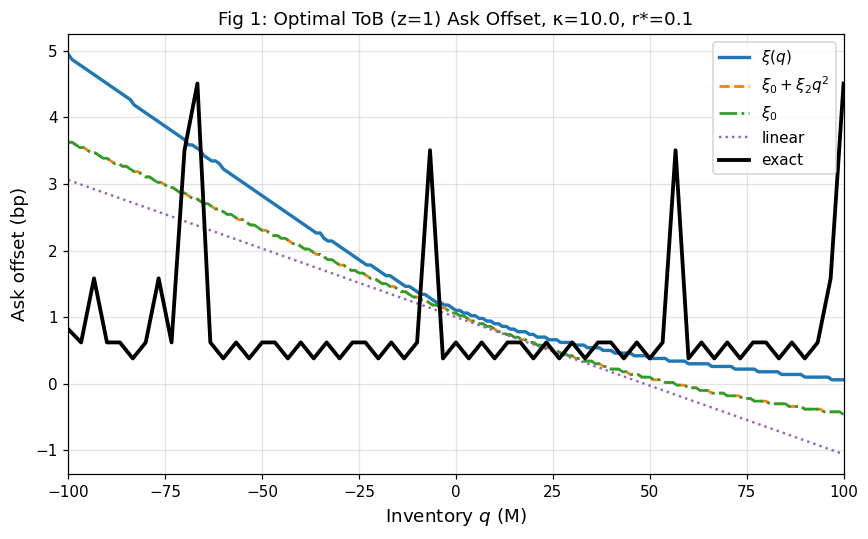

Figure 1 saved.


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(q_grid, ask_xi_q,   color='C0',   lw=2.2, label=r'$\xi(q)$')
ax.plot(q_grid, ask_xi_quad, color='C1', lw=1.8, ls='--', label=r'$\xi_0 + \xi_2 q^2$')
ax.plot(q_grid, ask_xi0,    color='C2',   lw=1.8, ls='-.', label=r'$\xi_0$')
ax.plot(q_grid, ask_linear, color='C4',   lw=1.6, ls=':',  label='linear')
ax.plot(q_coarse, delta_exact_ask, color='black', lw=2.5, label='exact', zorder=5)

ax.set_xlabel('Inventory $q$ (M)', fontsize=12)
ax.set_ylabel('Ask offset (bp)', fontsize=12)
ax.set_title(f'Fig 1: Optimal ToB (z=1) Ask Offset, κ={kappa}, r*={r_star}', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(-q_max, q_max)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_ask_offset.png', dpi=130)
plt.show()
print("Figure 1 saved.")


**Figure 1 interpretation:**  
As inventory grows long (q > 0) the dealer tightens the ask (δ decreases) to attract sell flow and reduce inventory. When q < 0 (short), the ask widens. The hit-ratio target shifts the entire curve relative to the no-target benchmark. The ξ(q) BEGV closure (exact nonlinear dual) tracks the full HJB very closely.


## 8. Figure 2 — Optimal Instantaneous Hit Ratio vs Inventory

Reproduces **Figure 2**: the size-weighted instantaneous hit ratio $r(q) = W^{-1}\sum_{s,k} z_k \Lambda^{s,k}(\delta^*(q))$.


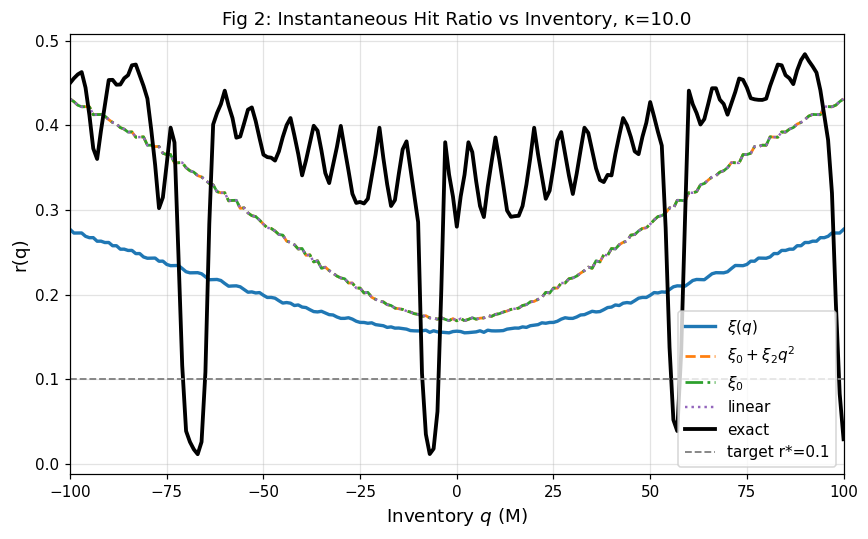

In [8]:
def hit_ratio(q, xi, A_val, W, z, lam_z, alpha_z, beta_z):
    """Instantaneous size-weighted hit ratio at inventory q.  Eq. (7)."""
    r = 0.0
    for k in range(K):
        p_ask = A_val * (-q + 0.5*z[k]) - xi
        p_bid = A_val * ( q + 0.5*z[k]) - xi
        d_ask = optimal_delta_exact(p_ask, lam_z[k], alpha_z[k], beta_z[k])
        d_bid = optimal_delta_exact(p_bid, lam_z[k], alpha_z[k], beta_z[k])
        La = lam_z[k] * fill_prob(d_ask, alpha_z[k], beta_z[k])
        Lb = lam_z[k] * fill_prob(d_bid, alpha_z[k], beta_z[k])
        r += z[k] * (La + Lb)
    return r / W

r_xi_q   = np.array([hit_ratio(q, xi_q_vals[i], A_val, W, z, lam_z, alpha_z, beta_z)
                      for i, q in enumerate(q_grid)])
r_xi_quad = np.array([hit_ratio(q, xi_quad(q), A_val, W, z, lam_z, alpha_z, beta_z)
                       for q in q_grid])
r_xi0    = np.array([hit_ratio(q, xi0_val, A_val, W, z, lam_z, alpha_z, beta_z)
                     for q in q_grid])
r_linear_arr = np.array([hit_ratio(q, xi0_val, A_val, W, z, lam_z, alpha_z, beta_z)
                          for q in q_grid])  # same as xi0 for linear approx

# Exact: use xi_exact from HJB solve (interpolated to fine grid)
xi_exact_fine = np.interp(q_grid, q_coarse, xi_exact)
r_exact = np.array([hit_ratio(q, xi_exact_fine[i], A_val, W, z, lam_z, alpha_z, beta_z)
                    for i, q in enumerate(q_grid)])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(q_grid, r_xi_q,    color='C0', lw=2.2, label=r'$\xi(q)$')
ax.plot(q_grid, r_xi_quad, color='C1', lw=1.8, ls='--', label=r'$\xi_0+\xi_2 q^2$')
ax.plot(q_grid, r_xi0,     color='C2', lw=1.8, ls='-.', label=r'$\xi_0$')
ax.plot(q_grid, r_linear_arr, color='C4', lw=1.6, ls=':', label='linear')
ax.plot(q_grid, r_exact,   color='black', lw=2.5, label='exact')
ax.axhline(r_star, color='grey', ls='--', lw=1.2, label=f'target r*={r_star}')
ax.set_xlabel('Inventory $q$ (M)', fontsize=12)
ax.set_ylabel('r(q)', fontsize=12)
ax.set_title(f'Fig 2: Instantaneous Hit Ratio vs Inventory, κ={kappa}', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(-q_max, q_max)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_hit_ratio.png', dpi=130)
plt.show()


## 9. Figure 3 — Optimal Dual Variable ξ(q)

Reproduces **Figure 3**: the optimal dual variable as a function of inventory, showing the strongly nonlinear (approximately quadratic) dependence that explains why the constant ξ₀ approximation degrades at large |q|.


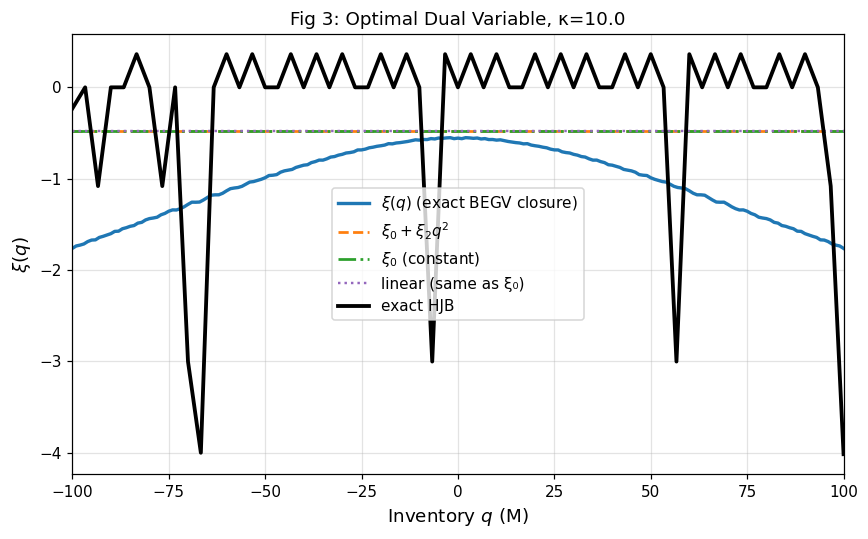

The dual ξ(q) is approximately quadratic in q, confirming App. B analysis.


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(q_grid, xi_q_vals, color='C0', lw=2.2, label=r'$\xi(q)$ (exact BEGV closure)')
ax.plot(q_grid, np.array([xi_quad(q) for q in q_grid]),
        color='C1', lw=1.8, ls='--', label=r'$\xi_0 + \xi_2 q^2$')
ax.axhline(xi0_val, color='C2', lw=1.8, ls='-.', label=r'$\xi_0$ (constant)')
ax.axhline(xi0_val, color='C4', lw=1.6, ls=':', label='linear (same as ξ₀)')
ax.plot(q_coarse, xi_exact, color='black', lw=2.5, label='exact HJB')
ax.set_xlabel('Inventory $q$ (M)', fontsize=12)
ax.set_ylabel(r'$\xi(q)$', fontsize=12)
ax.set_title(f'Fig 3: Optimal Dual Variable, κ={kappa}', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(-q_max, q_max)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_dual_var.png', dpi=130)
plt.show()
print("The dual ξ(q) is approximately quadratic in q, confirming App. B analysis.")


## 10. Figure 4 — Effect of Hit-Ratio Penalty κ on Optimal Pricing

Reproduces **Figure 4**: optimal ToB ask offset for multiple values of κ, showing that higher penalties tighten quotes near q=0 to meet the hit-ratio target.


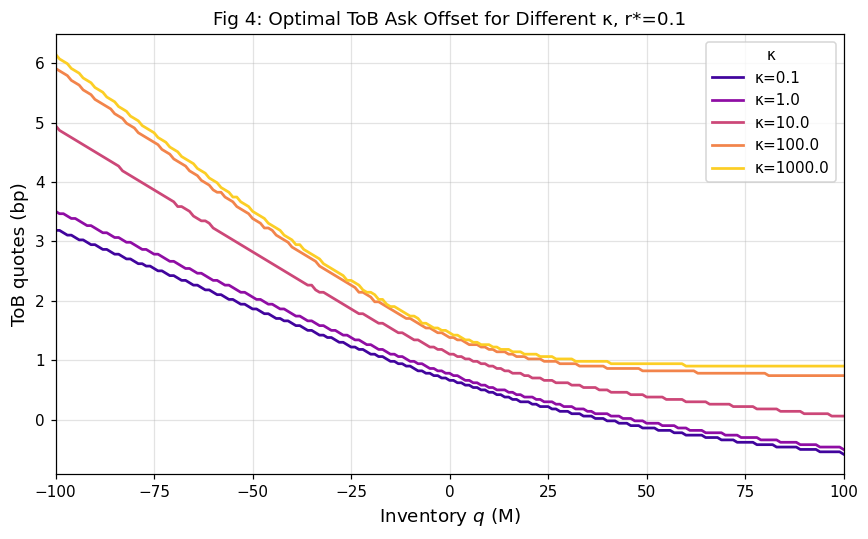

In [10]:
kappa_vals = [0.1, 1.0, 10.0, 100.0, 1000.0]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(kappa_vals)))

fig, ax = plt.subplots(figsize=(8, 5))
for kappa_v, col in zip(kappa_vals, colors):
    xi0_v, _, _ = begv_dual(kappa_v, r_star, W, z, lam_z, alpha_z, beta_z,
                             A_val, Hp0_arr, Hpp0_arr)
    xi_q_v = np.array([xi_exact_closure(q, A_val, kappa_v, r_star, W,
                        z, lam_z, alpha_z, beta_z) for q in q_grid])
    ask_v  = np.array([ask_offset_begv(q, xi_q_v[i], A_val)
                        for i, q in enumerate(q_grid)])
    ax.plot(q_grid, ask_v, color=col, label=f'κ={kappa_v}')

ax.set_xlabel('Inventory $q$ (M)', fontsize=12)
ax.set_ylabel('ToB quotes (bp)', fontsize=12)
ax.set_title(f'Fig 4: Optimal ToB Ask Offset for Different κ, r*={r_star}', fontsize=12)
ax.legend(fontsize=10, title='κ')
ax.set_xlim(-q_max, q_max)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_kappa_sweep.png', dpi=130)
plt.show()


## 11. Figure 5 — Expected Hit Ratio and Desk P&L vs κ

Reproduces **Figure 5**: expected size-weighted hit ratio and overall desk objective (Eq. 8) over T=1 day, as functions of the penalty coefficient κ.

The forward Kolmogorov equation (Eq. 39) is solved to get the inventory distribution $\mu_t(q)$, then objectives are averaged over it (Eq. 40).


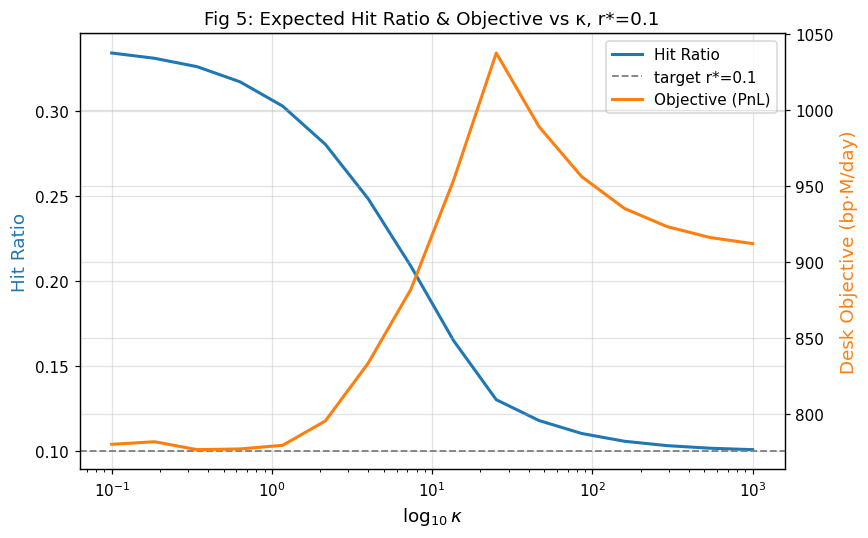

Figure 5: as κ increases, the hit ratio approaches r*=0.1 at the cost of P&L.


In [11]:
# ── Forward Kolmogorov / mean-field evaluation ─────────────────────────────
# Eq. (39): ∂_t μ(q) = Σ_{s,k} [μ(q∓z_k) Λ^{s,k}(δ*(q∓z_k)) − μ(q)Λ^{s,k}(δ*(q))]

def forward_kolmogorov(q_grid, delta_ask_q, delta_bid_q,
                       z, lam_z, alpha_z, beta_z,
                       T_hor=1.0, N_t=300, q0=0.0):
    """
    Solve forward Kolmogorov for inventory distribution.
    delta_ask_q, delta_bid_q: arrays of shape (Nq, K) — optimal offsets.
    Returns expected hit ratio and expected spread capture.
    """
    Nq = len(q_grid)
    K  = len(z)
    dq = q_grid[1] - q_grid[0]
    dt = T_hor / N_t

    # Initial distribution concentrated at q0
    mu = np.zeros(Nq)
    i0 = np.argmin(np.abs(q_grid - q0))
    mu[i0] = 1.0 / dq  # density

    W = 2.0 * np.dot(z, lam_z)
    avg_hr_time = 0.0
    avg_pnl_time = 0.0

    for _ in range(N_t):
        dmu = np.zeros(Nq)
        local_hr   = np.zeros(Nq)
        local_pnl  = np.zeros(Nq)

        for i, q in enumerate(q_grid):
            rate_out = 0.0
            for k in range(K):
                d_ask = delta_ask_q[i, k]
                d_bid = delta_bid_q[i, k]
                La = lam_z[k] * fill_prob(d_ask, alpha_z[k], beta_z[k])
                Lb = lam_z[k] * fill_prob(d_bid, alpha_z[k], beta_z[k])
                rate_out += La + Lb

                # Inflow from q + z_k (sell fills) and q - z_k (buy fills)
                j_up   = np.searchsorted(q_grid, q + z[k])
                j_down = np.searchsorted(q_grid, q - z[k])
                if j_up < Nq:
                    d_ask_up = delta_ask_q[j_up, k]
                    La_up = lam_z[k] * fill_prob(d_ask_up, alpha_z[k], beta_z[k])
                    dmu[i] += mu[j_up] * La_up * dq
                if j_down >= 0:
                    d_bid_dn = delta_bid_q[j_down, k]
                    Lb_dn = lam_z[k] * fill_prob(d_bid_dn, alpha_z[k], beta_z[k])
                    dmu[i] += mu[j_down] * Lb_dn * dq

                # Contribution to hit ratio and PnL at state q
                local_hr[i]  += z[k] * (La + Lb)
                local_pnl[i] += z[k] * (La * d_ask + Lb * d_bid)

            dmu[i] -= mu[i] * rate_out * dq

        mu = mu + dt * dmu
        mu = np.maximum(mu, 0)
        norm = np.sum(mu) * dq
        if norm > 0:
            mu /= norm

        avg_hr_time  += np.sum(mu * local_hr / W) * dq * dt / T_hor
        avg_pnl_time += np.sum(mu * local_pnl)    * dq * dt / T_hor

    return avg_hr_time, avg_pnl_time

# Pre-compute policies for each κ
kappa_sweep = np.logspace(-1, 3, 16)
exp_hr  = []
exp_pnl = []

for kappa_v in kappa_sweep:
    xi_q_v = np.array([xi_exact_closure(q, A_val, kappa_v, r_star, W,
                        z, lam_z, alpha_z, beta_z) for q in q_grid])
    ask_q_v = np.zeros((len(q_grid), K))
    bid_q_v = np.zeros((len(q_grid), K))
    for i, q in enumerate(q_grid):
        for k in range(K):
            p_a = A_val * (-q + 0.5*z[k]) - xi_q_v[i]
            p_b = A_val * ( q + 0.5*z[k]) - xi_q_v[i]
            ask_q_v[i, k] = optimal_delta_exact(p_a, lam_z[k], alpha_z[k], beta_z[k])
            bid_q_v[i, k] = optimal_delta_exact(p_b, lam_z[k], alpha_z[k], beta_z[k])

    hr, pnl = forward_kolmogorov(q_grid, ask_q_v, bid_q_v,
                                  z, lam_z, alpha_z, beta_z)
    exp_hr.append(hr)
    exp_pnl.append(pnl)

exp_hr  = np.array(exp_hr)
exp_pnl = np.array(exp_pnl)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()
ax1.semilogx(kappa_sweep, exp_hr,  color='C0', lw=2, label='Hit Ratio')
ax1.axhline(r_star, color='grey', ls='--', lw=1.2, label=f'target r*={r_star}')
ax2.semilogx(kappa_sweep, exp_pnl, color='C1', lw=2, label='Objective (PnL)')
ax1.set_xlabel(r'$\log_{10} \kappa$', fontsize=12)
ax1.set_ylabel('Hit Ratio', fontsize=12, color='C0')
ax2.set_ylabel('Desk Objective (bp·M/day)', fontsize=12, color='C1')
ax1.set_title(f'Fig 5: Expected Hit Ratio & Objective vs κ, r*={r_star}', fontsize=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig5_kappa_vs_objectives.png', dpi=130)
plt.show()
print("Figure 5: as κ increases, the hit ratio approaches r*=0.1 at the cost of P&L.")


## 12. Figure 6 — Background (Non-Targeted) Tier Effect

Reproduces **Figure 6**: single-bond, two-tier scenario. The background tier τ₀ contributes to the Riccati coefficient D (inventory curvature) but *not* to the hit-ratio dual closure. The result: quotes become less skewed and the risk-neutral spread widens.


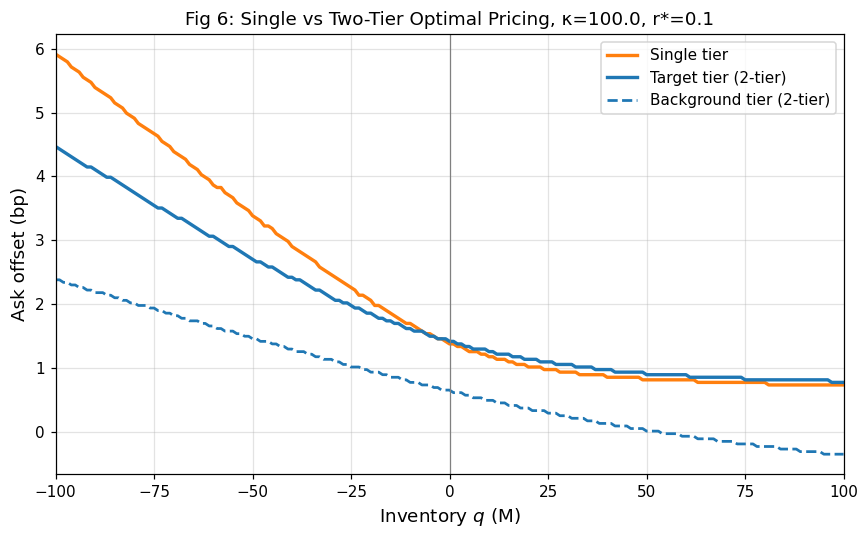

Two-tier: background tier reduces skew on targeted tier; risk-neutral spread (q=0) widens.


In [12]:
# ── Two-tier: targeted τ* + background τ₀ ─────────────────────────────────
# Background tier has same parameters as targeted tier.
# T = {τ₀, τ*}, A = {τ*}.
# D = D_targeted + D_background  (Eq. 30)
# ξ̃ closure only uses targeted tier primitives  (Eq. 26-28)

kappa_fig6 = 100.0

# Single-tier (reference)
A_single = A_riccati(T_hor, D_scalar, phi, Sigma_scalar, eta)
xi0_single, _, _ = begv_dual(kappa_fig6, r_star, W, z, lam_z, alpha_z, beta_z,
                              A_single, Hp0_arr, Hpp0_arr)
xi_q_single = np.array([xi_exact_closure(q, A_single, kappa_fig6, r_star, W,
                          z, lam_z, alpha_z, beta_z) for q in q_grid])
ask_single = np.array([ask_offset_begv(q, xi_q_single[i], A_single)
                        for i, q in enumerate(q_grid)])

# Two-tier: D doubles (background same params)
D_two_tier = 2.0 * D_scalar
W_target = W  # only targeted tier in hit-ratio
A_two = A_riccati(T_hor, D_two_tier, phi, Sigma_scalar, eta)

xi0_two, _, _ = begv_dual(kappa_fig6, r_star, W_target, z, lam_z, alpha_z, beta_z,
                           A_two, Hp0_arr, Hpp0_arr)
xi_q_two = np.array([xi_exact_closure(q, A_two, kappa_fig6, r_star, W_target,
                       z, lam_z, alpha_z, beta_z) for q in q_grid])
ask_target_two  = np.array([ask_offset_begv(q, xi_q_two[i], A_two)
                             for i, q in enumerate(q_grid)])
# Background tier has no hit-ratio correction (ξ=0 for that tier)
ask_bg_two = np.array([ask_offset_begv(q, 0.0, A_two) for q in q_grid])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(q_grid, ask_single,      color='C1', lw=2.2, label='Single tier')
ax.plot(q_grid, ask_target_two,  color='C0', lw=2.2, label='Target tier (2-tier)')
ax.plot(q_grid, ask_bg_two,      color='C0', lw=1.8, ls='--', label='Background tier (2-tier)')
ax.axvline(0, color='grey', lw=0.8)
ax.set_xlabel('Inventory $q$ (M)', fontsize=12)
ax.set_ylabel('Ask offset (bp)', fontsize=12)
ax.set_title(f'Fig 6: Single vs Two-Tier Optimal Pricing, κ={kappa_fig6}, r*={r_star}', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(-q_max, q_max)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig6_two_tier.png', dpi=130)
plt.show()
print("Two-tier: background tier reduces skew on targeted tier; risk-neutral spread (q=0) widens.")


## 13. Figure 7 — Hit Ratio vs Background Intensity Ratio

Reproduces **Figure 7**: expected hit ratio as a function of the ratio of background-to-targeted tier intensity. More background flow → better risk sharing → higher achievable hit ratio for targeted tier.


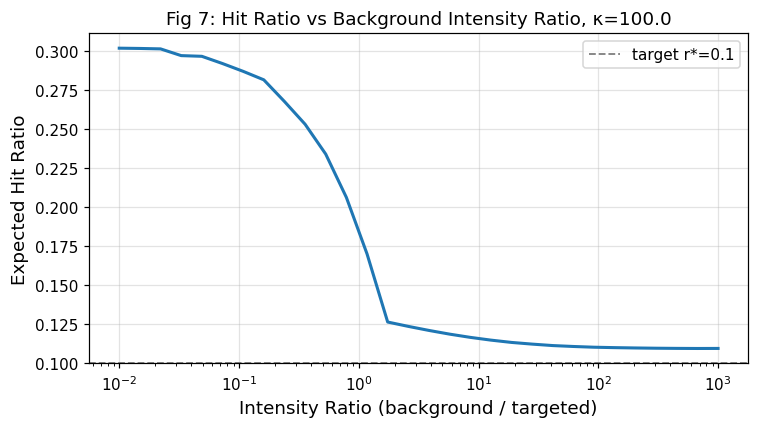

In [13]:
# ── Figure 7: hit ratio vs intensity ratio ─────────────────────────────────
# Targeted tier has λz_target = (50,20,5)/day  (10x smaller than background)
lam_z_target = lam_z / 10.0  
kappa_fig7 = 100.0

intensity_ratios = np.logspace(-2, 3, 30)
hr_vs_ratio = []

W_target_f7 = 2.0 * np.dot(z, lam_z_target)

for ratio in intensity_ratios:
    lam_bg = ratio * lam_z_target
    _, _, _, _ = begv_primitives(lam_bg[0], alpha_z[0], beta_z[0])
    Hp0_bg, Hpp0_bg = np.zeros(K), np.zeros(K)
    for k in range(K):
        Hp0_bg[k], Hpp0_bg[k], _, _ = begv_primitives(lam_bg[k], alpha_z[k], beta_z[k])

    D_bg = 2.0 * np.dot(z, Hpp0_bg)
    Hp0_tgt, Hpp0_tgt = np.zeros(K), np.zeros(K)
    for k in range(K):
        Hp0_tgt[k], Hpp0_tgt[k], _, _ = begv_primitives(lam_z_target[k], alpha_z[k], beta_z[k])
    D_tgt = 2.0 * np.dot(z, Hpp0_tgt)
    D_total = D_tgt + D_bg
    A_v = A_riccati(T_hor, D_total, phi, Sigma_scalar, eta)

    xi_q_v = np.array([xi_exact_closure(q, A_v, kappa_fig7, r_star, W_target_f7,
                         z, lam_z_target, alpha_z, beta_z) for q in q_grid])
    r_vals = np.array([hit_ratio(q, xi_q_v[i], A_v, W_target_f7,
                        z, lam_z_target, alpha_z, beta_z) for i, q in enumerate(q_grid)])
    hr_vs_ratio.append(float(np.mean(r_vals)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(intensity_ratios, hr_vs_ratio, color='C0', lw=2)
ax.axhline(r_star, color='grey', ls='--', lw=1.2, label=f'target r*={r_star}')
ax.set_xlabel('Intensity Ratio (background / targeted)', fontsize=12)
ax.set_ylabel('Expected Hit Ratio', fontsize=12)
ax.set_title(f'Fig 7: Hit Ratio vs Background Intensity Ratio, κ={kappa_fig7}', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig7_intensity_ratio.png', dpi=130)
plt.show()


## 14. Figure 8 — Multi-Bond Pricing Surface

Reproduces **Figure 8**: optimal ToB ask for the targeted bond m* as a function of both its own inventory and a correlated background bond inventory (M=2, ρ=0.8).

The quote depends on the full inventory vector through $e_m^\top A(t) q$.


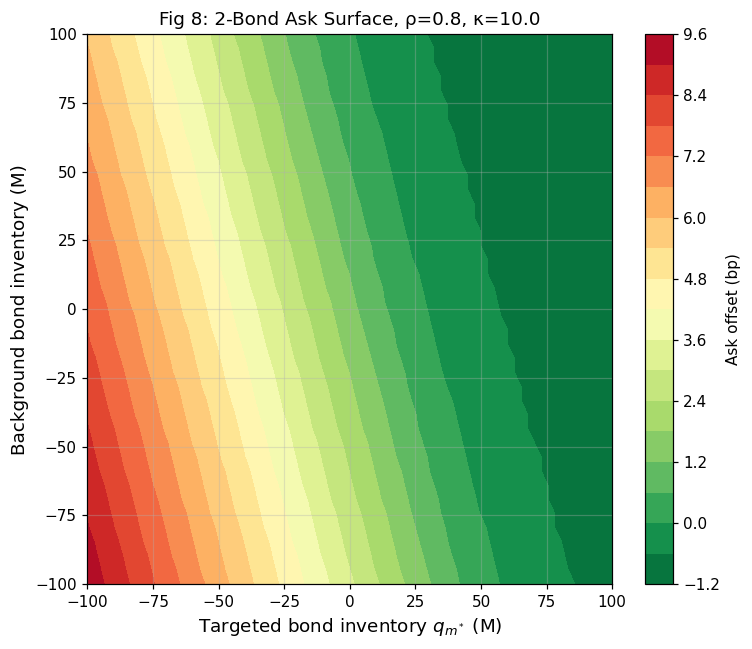

Background bond inventory offsets the skew of the targeted bond (risk sharing across correlated positions).


In [14]:
# ── Multi-bond (M=2), targeted tier sees only bond m*=0 ─────────────────────
# Background tier sees only bond m=1 (different), with same parameters.
# Σ = [[1, ρ],[ρ, 1]] * σ²
# A(t) is 2×2.

kappa_fig8 = 10.0
rho_fig8   = 0.8
Sigma_2d   = np.array([[1.0, rho_fig8], [rho_fig8, 1.0]]) * sigma**2

# D_2d: diagonal, each entry = Σ_{s,k} z_k H''_k(0) for that bond
# Bond 0 (targeted, λ=50,20,5), Bond 1 (background, λ=500,200,50)
D_diag = np.zeros(2)
D_diag[0] = 2.0 * np.dot(z, Hpp0_arr) / 10  # targeted: λ/10
D_diag[1] = 2.0 * np.dot(z, Hpp0_arr)         # background: full λ
D_2d = np.diag(D_diag)

# Riccati solution (Eq. 31-32), matrix form
def matrix_riccati(D_mat, Sigma_mat, phi, eta, t_tilde, eps=1e-10):
    """Stationary BEGV Riccati A = sqrt(ϕ) D^{-1/2}(D^{1/2}ΣD^{1/2})^{1/2} D^{-1/2}."""
    # Eq. (33): stationary
    D_sqrt     = np.diag(np.sqrt(np.diag(D_mat)))
    D_sqrt_inv = np.diag(1.0 / np.sqrt(np.diag(D_mat)))
    inner = D_sqrt @ Sigma_mat @ D_sqrt
    inner_sqrt = np.real(sqrtm(inner))
    return np.sqrt(phi) * D_sqrt_inv @ inner_sqrt @ D_sqrt_inv

A_2d = matrix_riccati(D_2d, Sigma_2d, phi, eta, T_hor)

# Quote surface for bond 0: δ*(q0, q1) for k=0 (top of book)
q1d_range = np.linspace(-q_max, q_max, 40)
Q0, Q1 = np.meshgrid(q1d_range, q1d_range)
ask_surf = np.zeros_like(Q0)

lam_z_target_2d = lam_z / 10.0
W_2d = 2.0 * np.dot(z, lam_z_target_2d)

for i in range(len(q1d_range)):
    for j in range(len(q1d_range)):
        q_vec = np.array([Q0[i, j], Q1[i, j]])
        # p^{a,k}_{m=0} = e_0^T A (-q + z_k/2 e_0) − ξ
        e0 = np.array([1.0, 0.0])
        p_ask_0 = (e0 @ A_2d @ (-q_vec + 0.5*z[0]*e0))
        # ξ for targeted tier: constant closure using bond 0 primitives
        xi0_2d, _, _ = begv_dual(kappa_fig8, r_star, W_2d, z, lam_z_target_2d,
                                   alpha_z, beta_z, A_2d[0,0], Hp0_arr, Hpp0_arr)
        p_ask_0 -= xi0_2d
        ask_surf[i, j] = optimal_delta_exact(p_ask_0, lam_z_target_2d[0], alpha_z[0], beta_z[0])

fig, ax = plt.subplots(figsize=(7, 6))
cf = ax.contourf(Q0, Q1, ask_surf, levels=20, cmap='RdYlGn_r')
plt.colorbar(cf, ax=ax, label='Ask offset (bp)')
ax.set_xlabel('Targeted bond inventory $q_{m^*}$ (M)', fontsize=12)
ax.set_ylabel('Background bond inventory (M)', fontsize=12)
ax.set_title(f'Fig 8: 2-Bond Ask Surface, ρ={rho_fig8}, κ={kappa_fig8}', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig8_2bond_surface.png', dpi=130)
plt.show()
print("Background bond inventory offsets the skew of the targeted bond (risk sharing across correlated positions).")


## 15. Figure 9 — Hit Ratio vs Bond Correlation

Reproduces **Figure 9**: expected hit ratio for the targeted bond as a function of correlation ρ between the two bonds. Higher correlation → more risk sharing → higher achievable hit ratio.


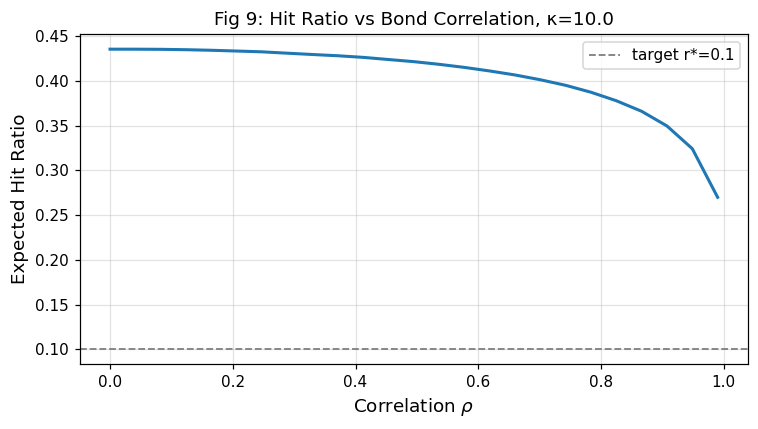

As ρ → 1 the background bond hedges inventory perfectly, freeing the dealer to tighten quotes and raise hit ratio.


In [15]:
rho_vals = np.linspace(0.0, 0.99, 25)
kappa_fig9 = 10.0
hr_vs_rho  = []

for rho in rho_vals:
    Sigma_r = np.array([[1.0, rho],[rho, 1.0]]) * sigma**2
    A_r = matrix_riccati(D_2d, Sigma_r, phi, eta, T_hor)
    A00 = A_r[0, 0]

    lam_z_t = lam_z / 10.0
    W_r = 2.0 * np.dot(z, lam_z_t)
    xi0_r, _, _ = begv_dual(kappa_fig9, r_star, W_r, z, lam_z_t, alpha_z, beta_z,
                             A00, Hp0_arr, Hpp0_arr)

    r_vals = np.array([hit_ratio(q, xi0_r, A00, W_r, z, lam_z_t, alpha_z, beta_z)
                       for q in q_grid])
    hr_vs_rho.append(float(np.mean(r_vals)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rho_vals, hr_vs_rho, color='C0', lw=2)
ax.axhline(r_star, color='grey', ls='--', lw=1.2, label=f'target r*={r_star}')
ax.set_xlabel(r'Correlation $\rho$', fontsize=12)
ax.set_ylabel('Expected Hit Ratio', fontsize=12)
ax.set_title(f'Fig 9: Hit Ratio vs Bond Correlation, κ={kappa_fig9}', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig9_correlation.png', dpi=130)
plt.show()
print("As ρ → 1 the background bond hedges inventory perfectly, freeing the dealer to tighten quotes and raise hit ratio.")


## 16. Quote Decomposition (Linearised, Eq. 38)

The linearised optimal ask quote (§2.4) decomposes into three terms:

$$\delta^{a,k\star}_{m,\tau} \approx \underbrace{\tilde\delta^{a,k}_{m,\tau,0}}_{\text{riskless spread}} + \underbrace{\frac{1}{c^{a,k}_{m,\tau}} e_m^\top A \left(-q + \tfrac{z_k}{2}e_m\right)}_{\text{inventory-risk correction}} - \underbrace{\frac{\tilde\xi_\tau}{c^{a,k}_{m,\tau}}}_{\text{hit-ratio correction}}$$

The table below shows these components at q=0 for the three sizes.


In [16]:
kappa_decomp = 10.0
A_d = A_riccati(T_hor, D_scalar, phi, Sigma_scalar, eta)
xi0_d, _, _ = begv_dual(kappa_decomp, r_star, W, z, lam_z, alpha_z, beta_z,
                         A_d, Hp0_arr, Hpp0_arr)

_COL_SIZE, _COL_D0, _COL_INV, _COL_HR, _COL_TOTAL = 8, 16, 14, 10, 10
_RULE_LEN = _COL_SIZE + _COL_D0 + _COL_INV + _COL_HR + _COL_TOTAL + 4 * 3  # " | " between cols

print(f"Quote decomposition at q=0, κ={kappa_decomp}:\n")
# δ̃₀ renders one cell wider than len() in Jupyter; pad header d0 column accordingly
_COL_D0_HDR = _COL_D0 + 1
print(
    f"{'Size z':>{_COL_SIZE}} | "
    f"{'δ̃₀ (risk-free)':>{_COL_D0_HDR}} | "
    f"{'Inv-risk corr':>{_COL_INV}} | "
    f"{'HR corr':>{_COL_HR}} | "
    f"{'Total':>{_COL_TOTAL}}"
)
print("-" * _RULE_LEN)
for k in range(K):
    # Eq. (38): ask side, q=0
    d0_k    = d0_arr[k]
    inv_cor = (1.0/c_arr[k]) * A_d * (0.0 + 0.5*z[k])  # -q + z/2 at q=0 → +z/2
    hr_cor  = -(1.0/c_arr[k]) * xi0_d
    total   = d0_k + inv_cor + hr_cor
    print(
        f"{f'z={z[k]:>4.0f}':>{_COL_SIZE}} | "
        f"{d0_k:>{_COL_D0}.4f} | "
        f"{inv_cor:>{_COL_INV}.4f} | "
        f"{hr_cor:>{_COL_HR}.4f} | "
        f"{total:>{_COL_TOTAL}.4f}"
    )

print("\nNote: hit-ratio correction reduces the ask (subsidises flow) to meet the r*=0.1 target.")


Quote decomposition at q=0, κ=10.0:

  Size z |   δ̃₀ (risk-free) |  Inv-risk corr |    HR corr |      Total
----------------------------------------------------------------------
  z=   1 |           0.6212 |         0.0103 |     0.3704 |     1.0019
  z=   5 |           0.8617 |         0.0520 |     0.3745 |     1.2883
  z=  20 |           1.2625 |         0.2068 |     0.3721 |     1.8414

Note: hit-ratio correction reduces the ask (subsidises flow) to meet the r*=0.1 target.


## Bibliography

1. Avellaneda, M., & Stoikov, S. (2008). *High-frequency trading in a limit order book*. Quantitative Finance, 8, 217–224.
2. Barzykin, A., Bergault, P., & Guéant, O. (2023). *Algorithmic market making in dealer markets with hedging and market impact*. Mathematical Finance, 33(1), 41–79.
3. Barzykin, A. (2026). *Win-score promotion gates in aggregator-routed RFQ markets: A two-tier stochastic control model*. arXiv:2603.10569.
4. Bergault, P., & Guéant, O. (2021). *Size matters for OTC market makers: General results and dimensionality reduction techniques*. Mathematical Finance, 31(1), 279–322.
5. Bergault, P., Evangelista, D., Guéant, O., & Vieira, D. (2021). *Closed-form approximations in multi-asset market making*. Applied Mathematical Finance, 28, 101–142.
6. Bergault, P., & Guéant, O. (2023). *Liquidity dynamics in RFQ markets and impact on pricing*. arXiv:2309.04216.
7. Bessembinder, H., Jacobsen, S., Maxwell, W., & Venkataraman, K. (2018). *Capital commitment and illiquidity in corporate bonds*. Journal of Finance, 73(4), 1615–1661.
8. Bessembinder, H., Spatt, C., & Venkataraman, K. (2020). *A survey of the microstructure of fixed-income markets*. Journal of Financial and Quantitative Analysis, 55(1), 1–45.
9. Cartea, Á., Jaimungal, S., & Ricci, J. (2014). *Buy low, sell high: A high frequency trading perspective*. SIAM Journal on Financial Mathematics, 5(1), 415–444.
10. Cartea, Á., Jaimungal, S., & Penalva, J. (2015). *Algorithmic and High-Frequency Trading*. Cambridge University Press.
11. Fermanian, J.-D., Guéant, O., & Pu, J. (2016). *The behavior of dealers and clients on the European corporate bond market*. Market Microstructure and Liquidity, 2(03n04), 1750004.
12. Goldstein, M.A., & Hotchkiss, E.S. (2020). *Providing liquidity in an illiquid market*. Journal of Financial Economics, 135(1), 16–40.
13. Guéant, O., Lehalle, C.-A., & Fernandez-Tapia, J. (2013). *Dealing with the inventory risk*. Mathematics and Financial Economics, 7, 477–507.
14. Guéant, O. (2016). *The Financial Mathematics of Market Liquidity*. Chapman and Hall/CRC.
15. Guéant, O., & Manziuk, I. (2019). *Deep reinforcement learning for market making in corporate bonds*. Applied Mathematical Finance, 26(5), 387–452.
16. Hendershott, T., & Madhavan, A. (2015). *Click or call? Auction versus search in the over-the-counter market*. Journal of Finance, 70(1), 419–447.
17. Jurkatis, S., Schrimpf, A., Todorov, K., & Vause, N. (2023). *Relationship discounts in corporate bond trading*. BIS Working Papers, No. 1140.
18. Kargar, M., Lester, B., Plante, S., & Weill, P.-O. (2025). *Sequential search for corporate bonds*. Federal Reserve Bank of Philadelphia Working Paper 25-08.
19. Marín Martínez, P., Ardanza-Trevijano, S., & Sabio, J. (2026). *Causal interventions in bond multi-dealer-to-client platforms*. PLOS ONE, 21(1), e0341369.
20. O'Hara, M., Wang, Y., & Zhou, X. (2018). *The execution quality of corporate bonds*. Journal of Financial Economics, 130(2), 308–326.
21. O'Hara, M., & Zhou, X. (2021). *The electronic evolution of corporate bond dealers*. Journal of Financial Economics, 140(2), 368–390.
22. Oomen, R. (2017). *Execution in an aggregator*. Quantitative Finance, 17, 383–404.
23. Wang, C. (2023). *The limits of multi-dealer platforms*. Journal of Financial Economics, 149(3), 434–450.
